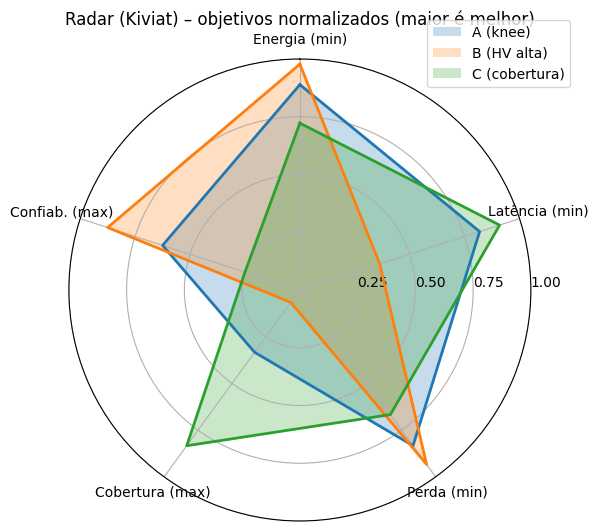

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def normalize_ideal_nadir(F, ideal, nadir, maximize=None):
    F = np.array(F, dtype=float)
    ideal = np.array(ideal, dtype=float)
    nadir = np.array(nadir, dtype=float)
    M = F.shape[1]
    if maximize is None:
        maximize = np.zeros(M, dtype=bool)  # default: minimização
    maximize = np.array(maximize, dtype=bool)
    S = np.empty_like(F, dtype=float)
    # max -> (f - ideal)/(nadir-ideal) ; min -> (nadir - f)/(nadir-ideal)
    denom = (nadir - ideal)
    denom[denom == 0] = 1.0
    S[:, maximize] = (F[:, maximize] - ideal[maximize]) / denom[maximize]
    S[:, ~maximize] = (nadir[~maximize] - F[:, ~maximize]) / denom[~maximize]
    # clip para evitar escapadas numéricas
    return np.clip(S, 0.0, 1.0)

def radar_plot_nsga(F, labels, ideal, nadir, maximize=None, names=None, alpha=0.25):
    """
    F: array (K x M) com valores dos objetivos das soluções
    labels: lista de nomes dos objetivos (len M)
    ideal, nadir: vetores (M)
    maximize: bool por objetivo (True=Maximiza); default tudo minimiza
    names: nomes das soluções (len K)
    """
    F = np.array(F, dtype=float)
    M = F.shape[1]
    angles = np.linspace(0, 2*np.pi, M, endpoint=False)
    angles = np.concatenate([angles, angles[:1]])  # fechar

    S = normalize_ideal_nadir(F, ideal, nadir, maximize)
    S = np.concatenate([S, S[:, :1]], axis=1)  # fechar polígonos

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # grades e rótulos dos eixos
    ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)
    ax.set_rgrids([0.25, 0.5, 0.75, 1.0], angle=90)
    ax.set_ylim(0, 1)

    if names is None:
        names = [f"sol {i}" for i in range(F.shape[0])]

    for s, name in zip(S, names):
        ax.plot(angles, s, linewidth=2)
        ax.fill(angles, s, alpha=alpha, label=name)

    ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
    ax.set_title("Radar (Kiviat) – objetivos normalizados (maior é melhor)")
    plt.show()

# ------------------ DEMO ------------------
# Exemplo: 5 objetivos (3 minimização, 2 maximização)
labels = ["Energia (min)", "Latência (min)", "Perda (min)", "Cobertura (max)", "Confiab. (max)"]
maximize = [False, False, False, True, True]

# ideal/nadir hipotéticos (p.ex., estimados da frente): 
ideal = np.array([0.1,  10,  0.0,  0.60, 0.90])  # melhor por objetivo
nadir = np.array([1.0, 120,  0.3,  0.90, 0.98])  # pior por objetivo

# três soluções da frente (valores brutos)
F = np.array([
    [0.20, 30, 0.05, 0.70, 0.95],  # solução A (equilibrada)
    [0.12, 80, 0.02, 0.62, 0.97],  # solução B (super energia, pior latência)
    [0.35, 20, 0.10, 0.85, 0.92],  # solução C (melhor cobertura)
])
names = ["A (knee)", "B (HV alta)", "C (cobertura)"]

radar_plot_nsga(F, labels, ideal, nadir, maximize, names)


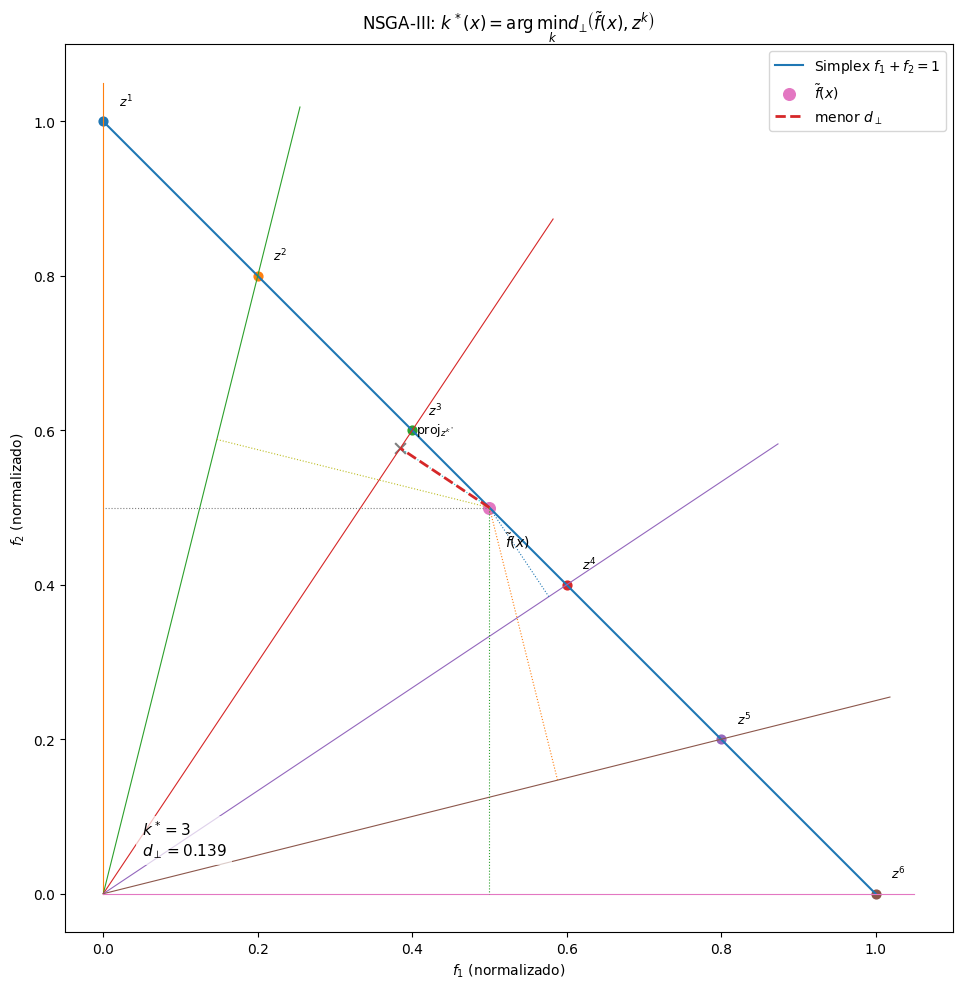

In [2]:
# NSGA-III niche association illustration (2D)
# Shows reference points on the unit simplex, a normalized objective point \tilde{f}(x),
# and perpendicular distance to each reference direction. Highlights the closest niche k*.
import numpy as np
import matplotlib.pyplot as plt

# --- Helpers ---
def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 0 else v

def perp_distance(p, z):
    """
    Perpendicular distance from point p to the ray along direction z (through origin).
    p, z are 2D vectors. Distance is || p - proj_z(p) ||.
    """
    d = unit(z)
    proj = np.dot(p, d) * d
    return np.linalg.norm(p - proj), proj

# --- Reference points on the 2D unit simplex f1 + f2 = 1 (first quadrant) ---
K = 6
ref_points = np.array([(i/(K-1), 1.0 - i/(K-1)) for i in range(K)])  # points on the simplex
ref_dirs = ref_points  # directions from origin to each reference point

# --- A sample normalized objective vector \tilde{f}(x) on the simplex ---
f = np.array([1.0, 1.0])  # arbitrary example
f = f / np.sum(f)           # normalize to the simplex
p = f.copy()

# Compute perpendicular distances to all reference directions
dists = []
projs = []
for z in ref_dirs:
    d, proj = perp_distance(p, z)
    dists.append(d)
    projs.append(proj)
dists = np.array(dists)
projs = np.array(projs)

k_star = int(np.argmin(dists))
p_proj_star = projs[k_star]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,10))

# Plot the unit simplex (line f1 + f2 = 1 in [0,1]^2)
ax.plot([0,1], [1,0], linewidth=1.5, label="Simplex $f_1+f_2=1$")

# Plot reference directions (rays) and points
for i, z in enumerate(ref_dirs):
    # ray from origin to near boundary for visualization (scaled to length 1.1 for clarity)
    ray_end = unit(z) * 1.05
    ax.plot([0, ray_end[0]], [0, ray_end[1]], linewidth=0.8)
    ax.scatter(ref_points[i,0], ref_points[i,1], s=40)
    ax.text(ref_points[i,0]+0.02, ref_points[i,1]+0.02, f"$z^{i+1}$", fontsize=9)

# Plot the normalized point \tilde{f}(x)
ax.scatter(p[0], p[1], s=70, marker="o", label=r"$\tilde{f}(x)$")
ax.text(p[0]+0.02, p[1]-0.05, r"$\tilde{f}(x)$", fontsize=10)

# Plot perpendicular segments to all reference directions (thin)
for i, proj in enumerate(projs):
    ax.plot([p[0], proj[0]], [p[1], proj[1]], linestyle=":", linewidth=0.8)

# Highlight the closest niche k*
ax.plot([p[0], p_proj_star[0]], [p[1], p_proj_star[1]], linestyle="--", linewidth=2.0, label=r"menor $d_\perp$")
ax.scatter(p_proj_star[0], p_proj_star[1], s=60, marker="x")
ax.text(p_proj_star[0]+0.02, p_proj_star[1]+0.02, r"$\mathrm{proj}_{z^{k^*}}$", fontsize=9)

# Annotate k*
ax.text(0.05, 0.05, rf"$k^* = {k_star+1}$" + "\n" + rf"$d_\perp = {dists[k_star]:.3f}$", fontsize=11,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Axes formatting
ax.set_aspect('equal', 'box')
ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel(r"$f_1$ (normalizado)")
ax.set_ylabel(r"$f_2$ (normalizado)")
ax.set_title(r"NSGA-III: $k^*(x)=\arg\min_k d_\perp\!\left(\tilde{f}(x), z^k\right)$")
ax.legend(loc="upper right")

# Save a copy to disk
out_path = "/mnt/data/nsga3_niche_association_2d.png"
plt.tight_layout()
plt.show()
